# Density compensation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/mrutils/blob/main/examples/density.ipynb)

`pipe_menon_dcf`: the sample weights that turn an adjoint NUFFT into a
direct image. Needs the `dcf` extra.

In [1]:
try:
    import mrutils  # noqa: F401
except ImportError:
    %pip install -q "mrutils[dcf]" matplotlib

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

warnings.filterwarnings("ignore", message="Samples will be rescaled")
warnings.filterwarnings("ignore", message="IProgress not found")

import mrinufft
import mrutils as mru


def phantom(n=128):
    """A Shepp-Logan phantom on an n x n grid."""
    y, x = np.mgrid[-1 : 1 : n * 1j, -1 : 1 : n * 1j]
    ellipses = [
        # value, centre x, centre y, semi-axis a, semi-axis b, degrees
        (1.0, 0.0, 0.0, 0.69, 0.92, 0),
        (-0.8, 0.0, -0.0184, 0.6624, 0.874, 0),
        (-0.2, 0.22, 0.0, 0.11, 0.31, -18),
        (-0.2, -0.22, 0.0, 0.16, 0.41, 18),
        (0.1, 0.0, 0.35, 0.21, 0.25, 0),
        (0.1, 0.0, 0.1, 0.046, 0.046, 0),
        (0.1, 0.0, -0.1, 0.046, 0.046, 0),
        (0.1, -0.08, -0.605, 0.046, 0.023, 0),
        (0.1, 0.0, -0.606, 0.023, 0.023, 0),
        (0.1, 0.06, -0.605, 0.023, 0.046, 0),
    ]
    image = np.zeros((n, n))
    for value, cx, cy, a, b, degrees in ellipses:
        angle = np.deg2rad(degrees)
        xr = (x - cx) * np.cos(angle) + (y - cy) * np.sin(angle)
        yr = -(x - cx) * np.sin(angle) + (y - cy) * np.cos(angle)
        image[(xr / a) ** 2 + (yr / b) ** 2 <= 1.0] += value
    return image


n, n_spokes, n_read = 96, 256, 192
image = phantom(n).astype(np.complex64)

# Uniformly spaced radial, in normalized k: -0.5 is grid location -N/2. The
# angles are uniform so the sampling density is a function of |k| alone, which
# is what makes the closed form below something to check against.
angles = np.linspace(0.0, np.pi, n_spokes, endpoint=False)
radius = np.linspace(-0.5, 0.5, n_read, endpoint=False)
trajectory = np.stack(
    [np.outer(np.cos(angles), radius), np.outer(np.sin(angles), radius)], axis=-1
).reshape(-1, 2).astype(np.float32)
print(f"{n_spokes} spokes x {n_read} samples = {trajectory.shape[0]} samples "
      f"for a {n}x{n} image")

256 spokes x 192 samples = 49152 samples for a 96x96 image


## The weights

A non-Cartesian trajectory samples the middle of k-space far more densely than
its edge, so the adjoint transform of the measurement is the object convolved
with that density — for radial, a `1 / |k|` weighting, which is a wide
low-frequency haze over everything.

Pipe–Menon estimates the weights that undo it iteratively, and
`pipe_menon_dcf` is MRI-NUFFT's implementation of it with the result brought
back as a real, contiguous array. For radial the answer is known in closed
form — the weight rises linearly with `|k|` — which is what makes this a
check rather than a demonstration.

In [3]:
weights = np.asarray(mru.pipe_menon_dcf(trajectory, (n, n)))
k_radius = np.linalg.norm(trajectory, axis=-1)

print(f"weights: {weights.shape} {weights.dtype}, {weights.min():.3f} to {weights.max():.2f}")

# For radial the answer is known: the density of samples per unit area falls
# as 1/|k|, so the weight that undoes it rises as |k|. The outermost ring is
# left out of the fit -- those samples have no neighbours further out, so the
# estimator hands them a weight several times the trend, which is visible in
# the scatter below and is a property of every edge-of-k-space estimate.
interior = (k_radius > 0.05) & (k_radius < 0.45)
line = np.polyfit(k_radius[interior], weights[interior], 1)
explained = np.corrcoef(k_radius[interior], weights[interior])[0, 1] ** 2
print(f"a straight line explains {explained:.4f} of the variance over "
      f"0.05 < |k| < 0.45")
print(f"outermost samples run to {weights[k_radius > 0.49].max() / np.polyval(line, 0.5):.1f}x "
      f"that trend")

weights: (49152,) float32, 0.007 to 2.58
a straight line explains 0.9999 of the variance over 0.05 < |k| < 0.45
outermost samples run to 3.8x that trend


## What it is for

The compensated adjoint is a direct image: one transform, no iterations, and
close enough to look at. It is not a reconstruction — the residual below is
streaking from the trajectory itself, and no choice of weights removes it. That
is what a solve is for, and a solve does not need these weights: it needs a
preconditioner.

In [4]:
operator = mrinufft.get_operator("finufft")(trajectory, shape=(n, n), density=None)
measured = operator.op(image)

plain = operator.adj_op(measured)
compensated = operator.adj_op((measured * weights).astype(np.complex64))

normalize = lambda estimate: np.abs(estimate) / np.abs(estimate).max()
truth = normalize(image)
error = lambda estimate: float(
    np.linalg.norm(normalize(estimate) - truth) / np.linalg.norm(truth)
)
print(f"adjoint alone {error(plain):.2f}, density compensated {error(compensated):.2f}")

adjoint alone 2.33, density compensated 0.31


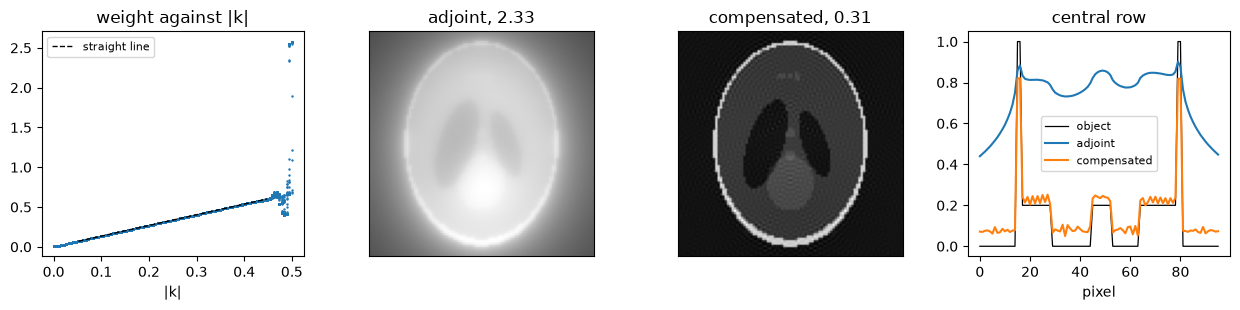

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12.5, 3.2))
axes[0].plot(k_radius[::13], weights[::13], ".", markersize=1.5)
axes[0].plot(
    np.sort(k_radius[interior]), np.polyval(line, np.sort(k_radius[interior])),
    "k--", linewidth=1, label="straight line",
)
axes[0].set_title("weight against |k|")
axes[0].set_xlabel("|k|")
axes[0].legend(fontsize=8)

for axis, estimate, title in (
    (axes[1], plain, f"adjoint, {error(plain):.2f}"),
    (axes[2], compensated, f"compensated, {error(compensated):.2f}"),
):
    axis.imshow(normalize(estimate), cmap="gray", vmin=0, vmax=1)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])

row = n // 2
axes[3].plot(truth[row], color="k", linewidth=0.9, label="object")
axes[3].plot(normalize(plain)[row], label="adjoint")
axes[3].plot(normalize(compensated)[row], label="compensated")
axes[3].set_title("central row")
axes[3].set_xlabel("pixel")
axes[3].legend(fontsize=8)
fig.tight_layout()

In [6]:
# Written only when the notebook runs inside a clone, and it is what the
# README shows -- so the figure in the README is always this cell's output.
figures = Path("figures")
if figures.is_dir():
    fig.savefig(figures / "density.png", dpi=110, bbox_inches="tight")